In [1]:
from matplotlib import pyplot as plt
import h5py
import numpy as np
import bacco

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

In [3]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/TNG_Family/MTNG/", snap=264)

2025-11-10 21:20:15,848 bacco.sims : Initialising simulation Default
2025-11-10 21:20:15,849 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-10 21:20:15,869 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-10 21:20:15,947 bacco.sims : ...done in 0.049 s


In [20]:
name_list = ["LH_"+str(i) for i in range(30)] + ["fiducial"]
snap = 264

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

zoom = {}
for i in range(len(name_list)):
    base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/"+name_list[i]+"/hydro_output/"
    zoom[name_list] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap),\
                            sim_format='TNG500', fixedPk=True, use_orphans=False, tau=tau, ns=ns, sigma8=sigma8,\
                            tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap), use_ids=True, numpart=4320)

2025-11-10 21:30:46,720 bacco.sims : Initialising simulation Default
2025-11-10 21:30:46,722 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/groups_264/fof_subhalo_tab_264
2025-11-10 21:30:46,725 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/groups_264/fof_subhalo_tab_264


2025-11-10 21:30:47,162 bacco.sims : ...done in 0.0108 s
2025-11-10 21:30:47,163 bacco.sims : Initialising simulation Default
2025-11-10 21:30:47,164 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/groups_264/fof_subhalo_tab_264
2025-11-10 21:30:47,181 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/groups_264/fof_subhalo_tab_264
2025-11-10 21:30:47,645 bacco.sims : ...done in 0.0339 s
2025-11-10 21:30:47,648 bacco.sims : Initialising simulation Default
2025-11-10 21:30:47,649 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/groups_264/fof_subhalo_tab_264
2025-11-10 21:30:47,669 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/groups_264/fof_subhalo_tab_264
2025-11-10 21:30:47,705 bacco.sims : ...done in 0.0371 s
2025-11-10 21:30:47,706 bacco.sims : Initialising simulation Default
2025-11-10 21:30:47,707 bacco.sims : try /cosmos_stora

In [21]:
pol = {}
for i in range(len(name_list)):
    pol[name_list[i]] = (zoom[name_list[i]].fof['halo_mfof_type'][:,2] + zoom[name_list[i]].fof['halo_mfof_type'][:,3]) / zoom[name_list[i]].fof['halo_mfof_type'][:,1]

2025-11-10 21:31:32,308 bacco.sims : Reading 142791 items for GroupMassType
2025-11-10 21:31:32,412 bacco.sims : Reading 143520 items for GroupMassType


2025-11-10 21:31:33,173 bacco.sims : Reading 146601 items for GroupMassType
2025-11-10 21:31:33,572 bacco.sims : Reading 141432 items for GroupMassType
2025-11-10 21:31:34,231 bacco.sims : Reading 145271 items for GroupMassType
2025-11-10 21:31:35,172 bacco.sims : Reading 145320 items for GroupMassType
2025-11-10 21:31:35,724 bacco.sims : Reading 146135 items for GroupMassType
2025-11-10 21:31:36,410 bacco.sims : Reading 139876 items for GroupMassType
2025-11-10 21:31:37,310 bacco.sims : Reading 142352 items for GroupMassType
2025-11-10 21:31:37,820 bacco.sims : Reading 144105 items for GroupMassType
2025-11-10 21:31:38,286 bacco.sims : Reading 135036 items for GroupMassType
2025-11-10 21:31:39,365 bacco.sims : Reading 139921 items for GroupMassType
2025-11-10 21:31:39,970 bacco.sims : Reading 141667 items for GroupMassType
2025-11-10 21:31:40,672 bacco.sims : Reading 142176 items for GroupMassType
2025-11-10 21:31:41,624 bacco.sims : Reading 144687 items for GroupMassType
2025-11-10 2

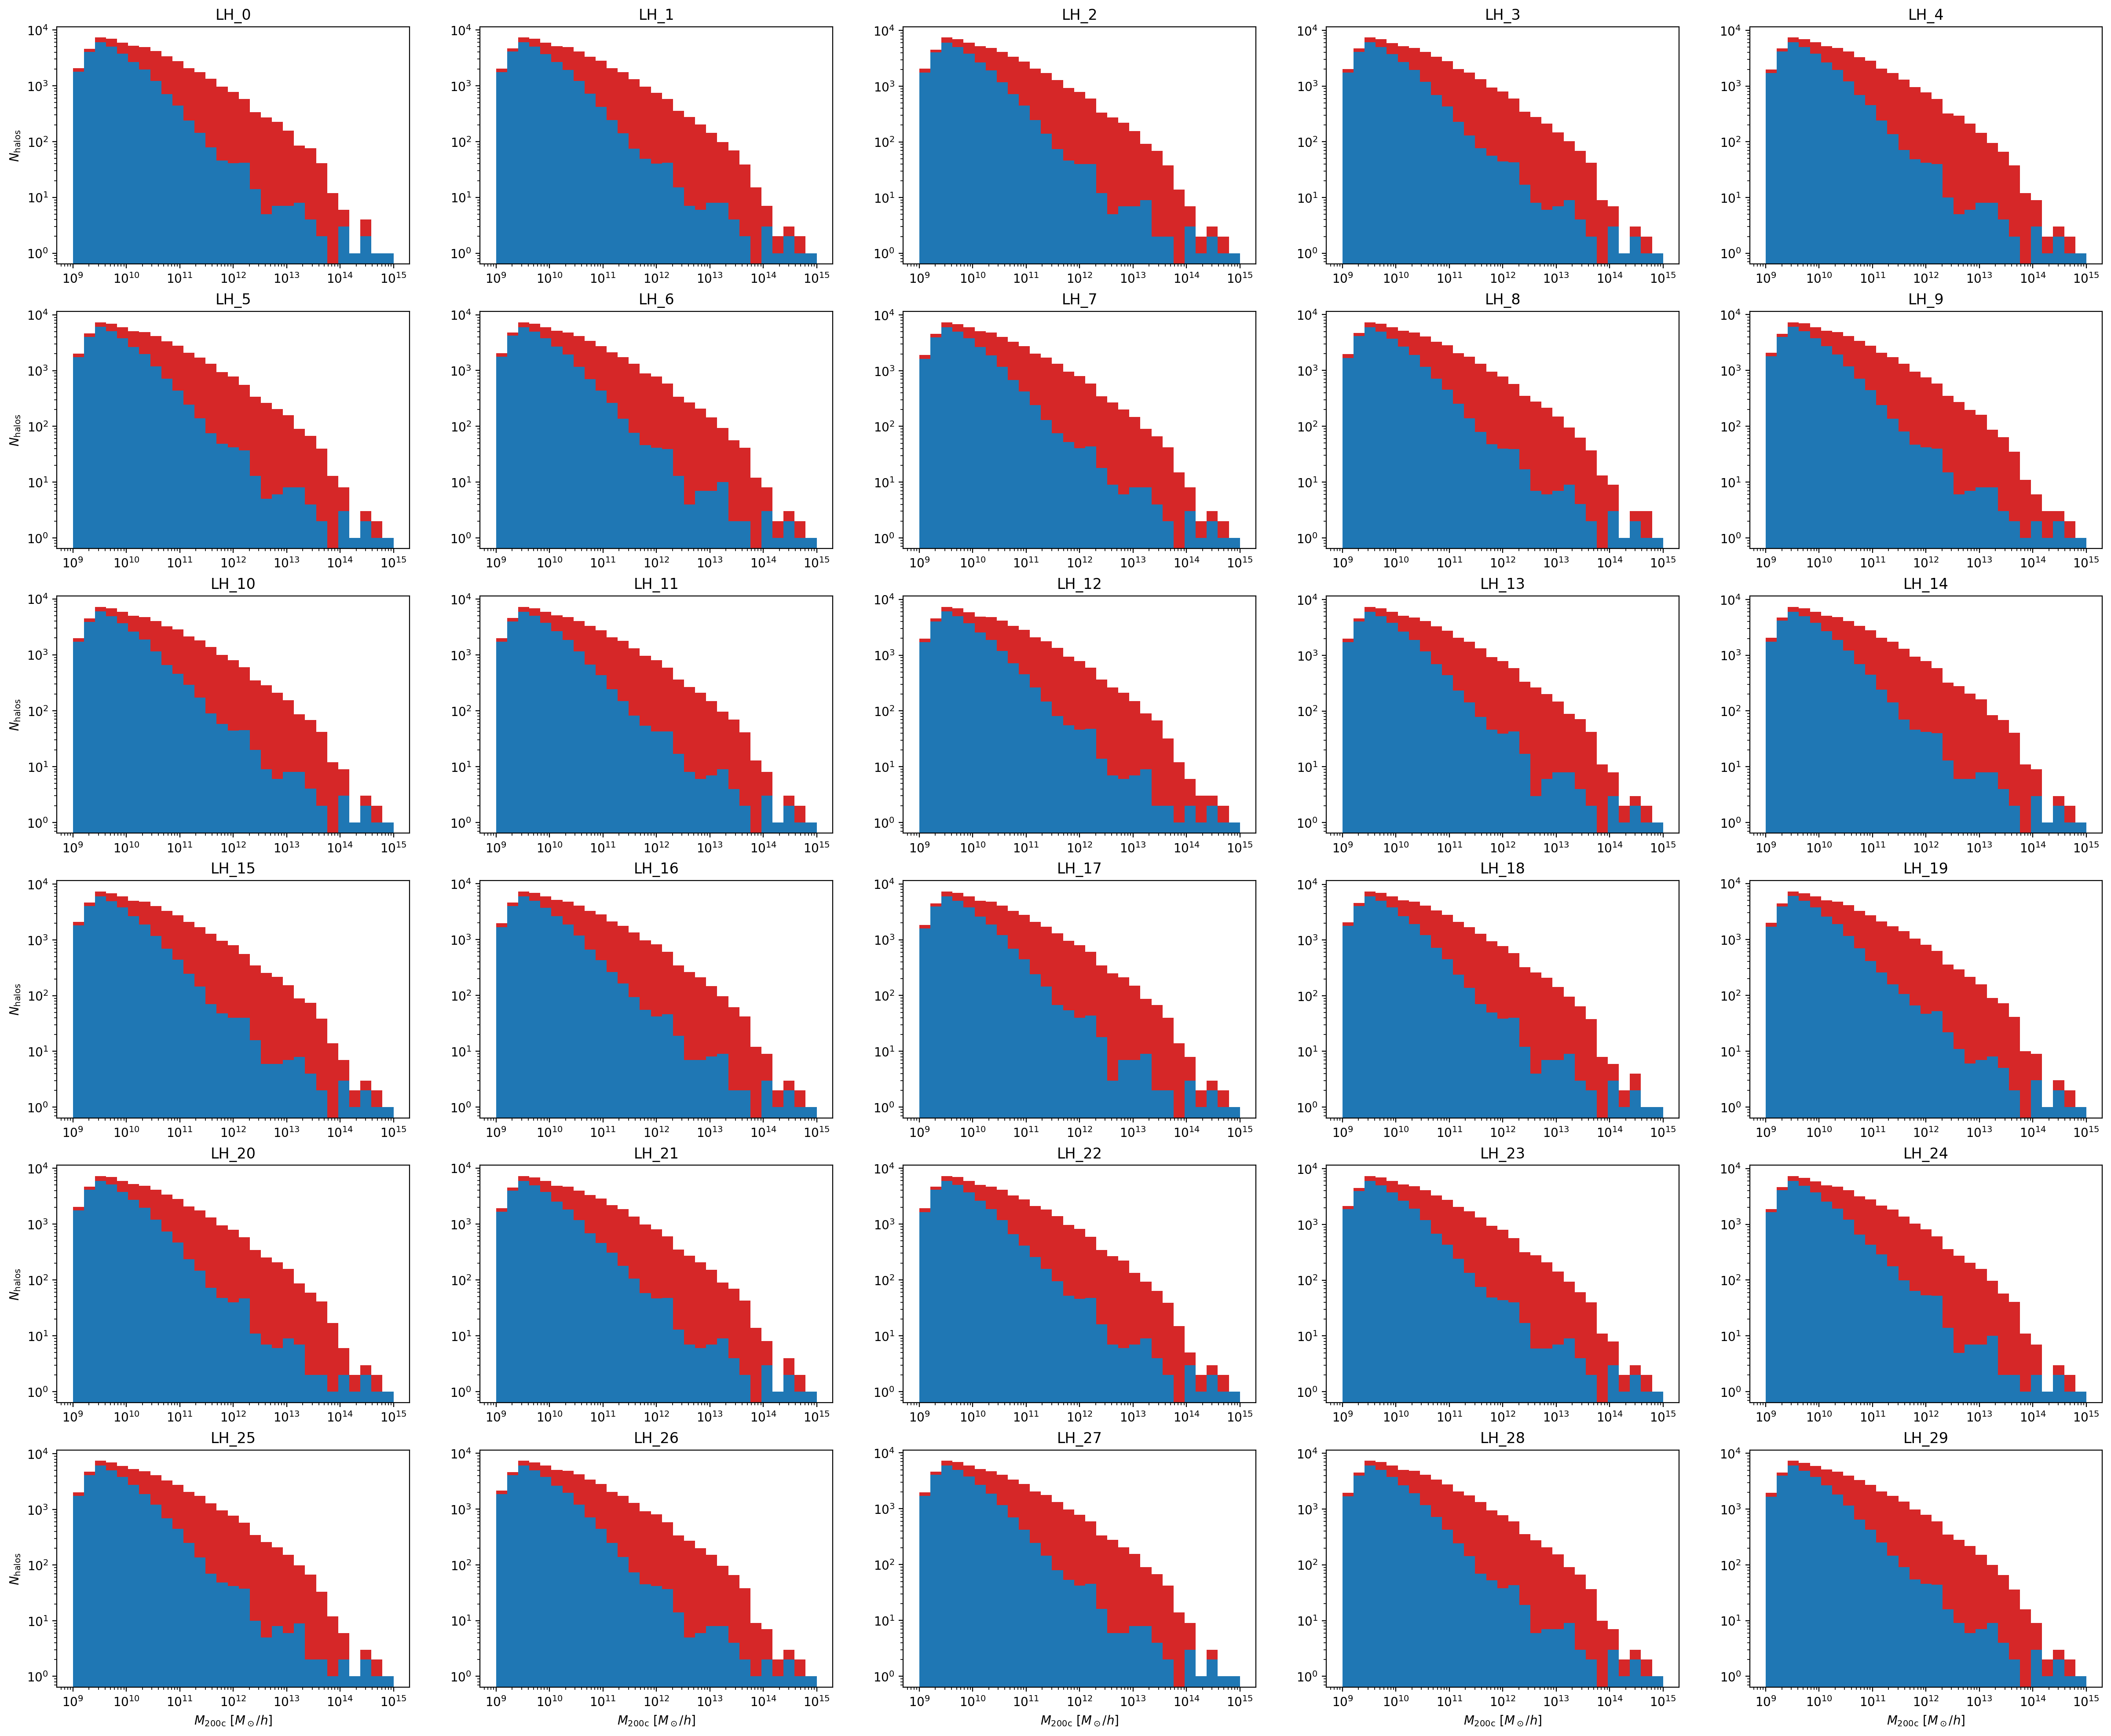

In [28]:
fig, ax = plt.subplots(6, 5, dpi=200, figsize=(30, 25))

for i in range(6):
    for j in range(5):
        ax[i,j].set_xscale('log')
        ax[i,j].set_yscale('log')

        ax[i,j].hist(1e10*zoom[name_list[5*i+j]].fof['halo_m200c'], color='C3', bins=np.logspace(9,15,30))
        ax[i,j].hist(1e10*zoom[name_list[5*i+j]].fof['halo_m200c'][pol[name_list[5*i+j]]<0.002], color='C0', bins=np.logspace(9,15,30))

        ax[i,j].set_title(name_list[5*i+j])

        if j==0:
           ax[i,j].set_ylabel(r"$N_\mathrm{halos}$")
        if i==5:
            ax[i,j].set_xlabel(r"$M_\mathrm{200c}\ [M_\odot/h]$")

Text(0.5, 0, '$M_\\mathrm{200c}\\ [M_\\odot/h]$')

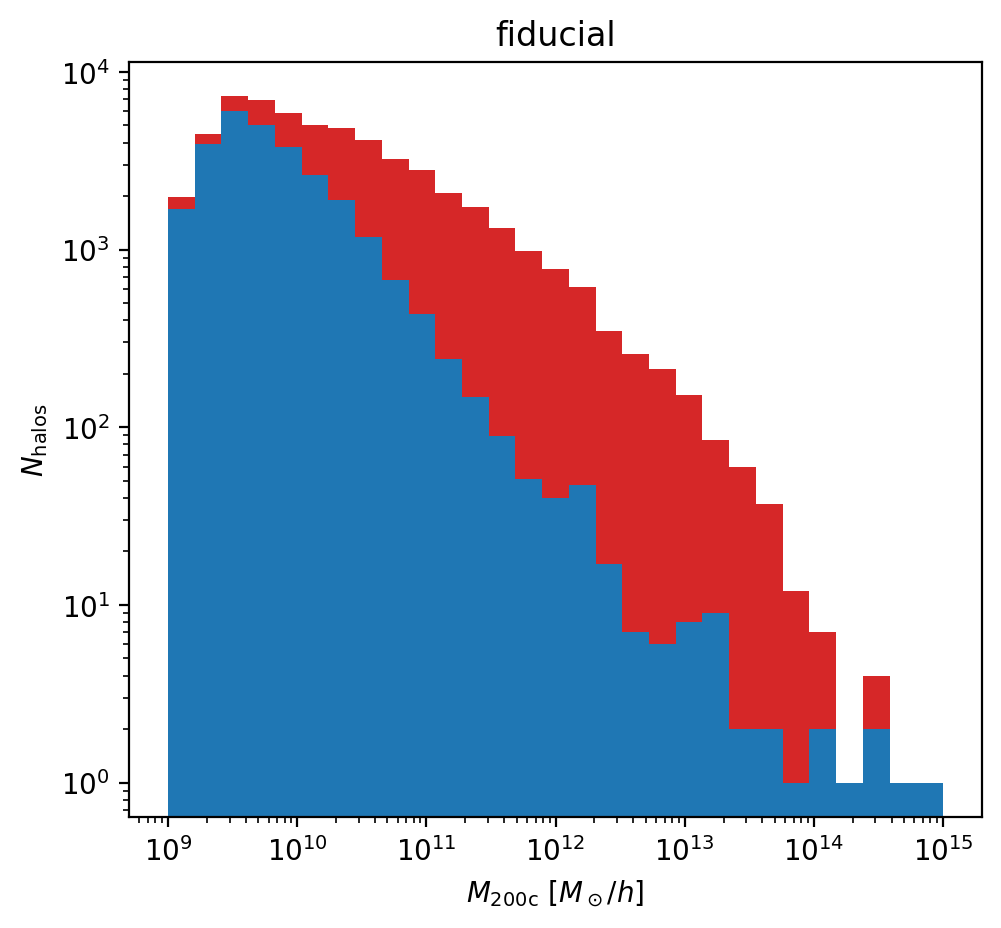

In [29]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5, 5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.hist(1e10*zoom['fiducial'].fof['halo_m200c'], color='C3', bins=np.logspace(9,15,30))
ax.hist(1e10*zoom['fiducial'].fof['halo_m200c'][pol['fiducial']<0.002], color='C0', bins=np.logspace(9,15,30))

ax.set_title('fiducial')

ax.set_ylabel(r"$N_\mathrm{halos}$")
ax.set_xlabel(r"$M_\mathrm{200c}\ [M_\odot/h]$")

In [52]:
xmatch = {}

for i in range(len(name_list)):
    xmatch[name_list[i]] = utils.cross_match(zoom[name_list[i]], snap=264)

2025-11-11 02:36:51,583 bacco.sims : Initialising simulation Default
2025-11-11 02:36:51,585 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-11 02:36:51,602 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264


2025-11-11 02:36:51,686 bacco.sims : ...done in 0.0468 s
2025-11-11 02:36:51,693 bacco.sims : Reading 98233510 items for GroupPos
2025-11-11 02:37:39,581 bacco.sims : Reading 90246895 items for SubhaloPos
2025-11-11 02:38:24,722 bacco.sims : Reading 98233510 items for Group_M_Mean200
2025-11-11 02:39:00,963 bacco.sims : Reading 90246895 items for SubhaloVmax
2025-11-11 02:39:49,100 bacco.sims : Reading 98233510 items for halo_firstsub
/cosmos_storage/home/fgmaion/MTNG-resims/src/utils.py:848: RuntimeWarning: divide by zero encountered in divide
  d_m = np.abs( (1 - m1[...,np.newaxis]/m2)/0.2 )
2025-11-11 02:40:20,725 bacco.sims : Initialising simulation Default
2025-11-11 02:40:20,727 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-11 02:40:20,729 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-11 02:40:20,769 bacco.sims : ...done in 0.0105 s
2025-11-11 02:40:20,776 bacco.sims : 

ValueError: Some input data are greater than the size of the periodic box.

In [53]:
base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/DM_only/output/"
zoom_dmo = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap),\
                        sim_format='TNG500', fixedPk=True, use_orphans=False, tau=tau, ns=ns, sigma8=sigma8,\
                        tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap), use_ids=True, numpart=4320)

2025-11-11 02:58:57,209 bacco.sims : Initialising simulation Default
2025-11-11 02:58:57,210 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/DM_only/output/groups_264/fof_subhalo_tab_264
2025-11-11 02:58:57,399 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/DM_only/output/groups_264/fof_subhalo_tab_264
2025-11-11 02:58:57,870 bacco.sims : ...done in 0.206 s


In [54]:
xmatch_dmo = utils.cross_match(zoom_dmo, snap=264)

2025-11-11 02:59:06,686 bacco.sims : Initialising simulation Default
2025-11-11 02:59:06,687 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-11 02:59:06,690 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-11 02:59:06,726 bacco.sims : ...done in 0.00772 s
2025-11-11 02:59:06,732 bacco.sims : Reading 98233510 items for GroupPos
2025-11-11 02:59:12,010 bacco.sims : Reading 90246895 items for SubhaloPos
2025-11-11 02:59:16,992 bacco.sims : Reading 72944 items for GroupPos
2025-11-11 02:59:17,237 bacco.sims : Reading 72944 items for Group_M_Mean200
2025-11-11 02:59:17,294 bacco.sims : Reading 98233510 items for Group_M_Mean200
2025-11-11 02:59:19,114 bacco.sims : Reading 74436 items for SubhaloVmax
2025-11-11 02:59:19,139 bacco.sims : Reading 72944 items for halo_firstsub
2025-11-11 02:59:19,187 bacco.sims : Reading 90246895 items for SubhaloVmax
2025-11-11 02:59:20,853 bacco.sims : R

Text(0, 0.5, '$N_\\mathrm{halos}$')

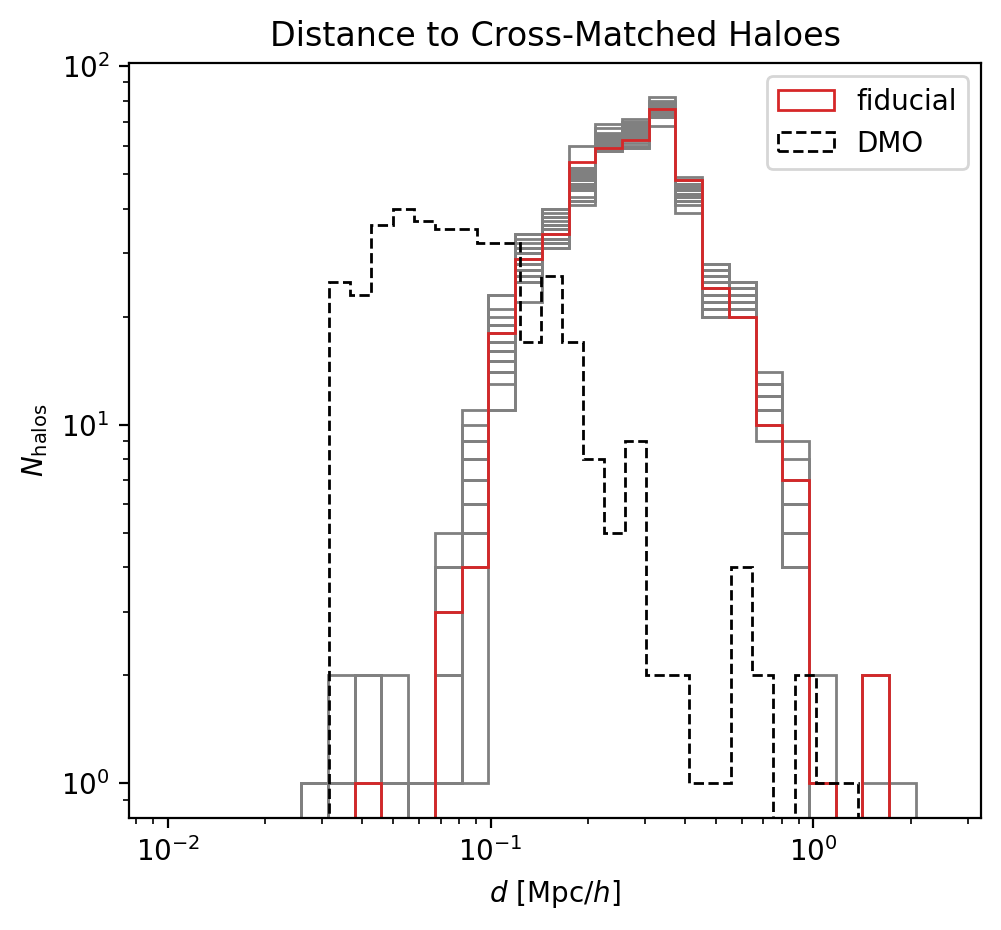

In [62]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5, 5))

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_title('Distance to Cross-Matched Haloes')

for i in range(len(name_list)-1):
    ax.hist(xmatch[name_list[i]]['d'], bins=np.logspace(-2,0.4,30), alpha=1, histtype='step', color='gray')

ax.hist(xmatch['fiducial']['d'], bins=np.logspace(-2,0.4,30), color='C3', alpha=1, label='fiducial', histtype='step')
ax.hist(xmatch_dmo['d'], bins=np.logspace(-1.5,0.4,30), alpha=1, label='DMO', histtype='step', color='k', linestyle='dashed')
ax.legend()

ax.set_xlabel(r"$d\ [\mathrm{Mpc}/h]$")
ax.set_ylabel(r"$N_\mathrm{halos}$")

In [77]:
def fgas_m500c(hydro):
    cont = hydro.fof['halo_masstyep']

    m500c = hydro.fof['halo_m500c'] * 1e10
    r500c = hydro.fof['halo_r500c']
    
    sel = np.where(m500c > 1e10)[0]
    fgas = np.zeros(len(sel))
    for i in range(len(sel)):
        dist = np.sqrt(np.sum((hydro.sub['pos'] - hydro.fof['halo_pos'][sel[i]])**2, axis=1))
        mask = dist < r500c[sel[i]]
        mgas_500c = np.sum(hydro.sub['MassType'][mask,0]*1e10)
        fgas[i] = mgas_500c / m500c[sel[i]]

    return fgas

In [78]:
old_hist = {}
new_hist = {}

for snap in range(100,245):
    LH0 = {}

    base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/old_LH0/hydro_output/"
    LH0["old"] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap),\
                            sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap),\
                            use_ids=True, numpart=4320)

    base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/"
    LH0["new"] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap),\
                            sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap),\
                            use_ids=True, numpart=4320)

    # sel_old = LH0['old'].sub['MassType'][:,4] > 0.1
    # sel_new = LH0['new'].sub['MassType'][:,4] > 0.1

    old_hist[snap] = np.histogram(np.log10(LH0['old'].sub['MassType'][:,4]*1e10), bins=np.linspace(9, 12, 31))[0]
    new_hist[snap] = np.histogram(np.log10(LH0['new'].sub['MassType'][:,4]*1e10), bins=np.linspace(9, 12, 31))[0]

2025-11-11 02:30:15,177 bacco.sims : Initialising simulation Default
2025-11-11 02:30:15,179 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/old_LH0/hydro_output/groups_100/fof_subhalo_tab_100
2025-11-11 02:30:15,198 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/old_LH0/hydro_output/groups_100/fof_subhalo_tab_100
2025-11-11 02:30:15,500 bacco.sims : ...done in 0.0554 s
2025-11-11 02:30:15,502 bacco.sims : Initialising simulation Default
2025-11-11 02:30:15,502 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/groups_100/fof_subhalo_tab_100
2025-11-11 02:30:15,520 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/groups_100/fof_subhalo_tab_100
2025-11-11 02:30:15,970 bacco.sims : ...done in 0.0381 s
2025-11-11 02:30:16,108 bacco.sims : Reading 119692 items for SubhaloMassType
/tmp/ipykernel_206947/2612984103.py:22: RuntimeWarning: divide by zero encountered in log10
  ol

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].set_yscale('log')

for snap in range(100,245):
    ax[0].plot(bin_centers, old_hist[snap], alpha=1, color='C0')
    ax[0].plot(bin_centers, new_hist[snap], alpha=1, color='C3')

ratio = np.zeros((145, 30))
for snap in range(100,245):
    ratio[snap-100,:] = old_hist[snap]/new_hist[snap]
    ax[1].plot(bin_centers, old_hist[snap]/new_hist[snap], alpha=0.5, color='C0')

ax[1].plot(bin_centers, np.mean(ratio, axis=0), color='k', lw=2)

ax[1].axhline(1, color='k', ls='--')
ax[1].set_ylim(0.5, 1.5)
